# TRIBE v2 Demo: Predicting Brain Responses to Naturalistic Stimuli

[TRIBE v2](https://github.com/facebookresearch/tribev2) is a deep multimodal brain encoding model that predicts **fMRI brain responses** to naturalistic stimuli — video, audio, and text.

It combines state-of-the-art feature extractors — **LLaMA 3.2** (text), **V-JEPA2** (video), and **Wav2Vec-BERT** (audio) — into a unified Transformer that maps multimodal representations onto the cortical surface (**fsaverage5**, ~20k vertices).

In this notebook, we will:
1. Load a pretrained TRIBE v2 model from HuggingFace
2. Predict brain responses to a **video** clip
3. Predict brain responses to **audio** generated from text
4. Visualize the predicted activity on a 3D brain surface

## Setup (for Colab users)

1. Activate the GPU (Menu > Runtime > Change runtime)
2. Run the command below
3. Restart your environment for the new packages to be taken into account

In [1]:
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

"uv" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


## Loading the model

We load TRIBE v2 model from [HuggingFace Hub](https://huggingface.co/facebook/tribev2). On the first run, this downloads the model checkpoint and config (~1 GB). Subsequent runs use the cached version.

We also initialize a `PlotBrain` object for 3D brain surface visualization using the **fsaverage5** mesh.

In [2]:
import pathlib
import os
import torch
import yaml

# 1. PARCHE CRÍTICO: Compatibilidad de rutas Linux (Posix) en Windows
if os.name == 'nt': 
    pathlib.PosixPath = pathlib.WindowsPath

# 2. Imports de la librería
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

# 3. Configuración de carpetas
CACHE_FOLDER = Path("./cache")
CACHE_FOLDER.mkdir(parents=True, exist_ok=True)

print(f"Iniciando TRIBE con Torch {torch.__version__}...")

# 4. Carga del modelo y el plotter
model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")

print("¡Listo! Modelo y visualizador cargados correctamente.")

C:\Users\UNE\Documents\VSCode\Tri-v2-meta\venv\Lib\site-packages\neuralset\extractors\base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-14 17:51:39 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


Iniciando TRIBE con Torch 2.6.0+cpu...


C:\Users\UNE\Documents\VSCode\Tri-v2-meta\venv\Lib\site-packages\neuralset\extractors\base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-14 17:51:49 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
INFO - Loading model from C:\Users\UNE\.cache\huggingface\hub\models--facebook--tribev2\snapshots\f894e783020944dcd96e5568550afe2aa9743f9f\best.ckpt
C:\Users\UNE\Documents\VSCode\Tri-v2-meta\venv\Lib\site-packages\x_transformers\x_transformers.py:439: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled = False)
C:\Users\UNE\Documents\VSCode\Tri-v2-meta\venv\

¡Listo! Modelo y visualizador cargados correctamente.


## Predict brain responses to a video

Given a video file, TRIBE v2 automatically:
1. **Extracts audio** from the video track
2. **Transcribes speech** into word-level events with timestamps using [**WhisperX**](https://github.com/m-bain/whisperx)
3. **Extracts visual features** (DINOv2 + V-JEPA2) and **audio features** (Wav2Vec-BERT) and **text features** (LLaMA 3.2)
4. **Predicts fMRI activity** at each time step (1 TR = 1 second) across the cortical surface

Below, we download a sample video ([Sintel trailer](https://durian.blender.org/)), build an events dataframe, and run the model.

In [3]:
video_path = CACHE_FOLDER / "sample_video.mp4"
url = "https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4"
download_file(url, video_path)
df = model.get_events_dataframe(video_path=video_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

INFO - Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache\sample_video.mp4
Extract audio from video events: 100%|███████████████████████████████████████████████████████████| 1/1 [00:00<?, ?it/s]
C:\Users\UNE\Documents\VSCode\Tri-v2-meta\venv\Lib\site-packages\neuralset\events\utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Extracting words from audio: 100%|███████████████████████████████████████████████████████| 1/1 [00:00<00:00, 74.21it/s]
C:\Users\UNE\Documents\VSCode\Tri-v2-meta\venv\Lib\site-packages\neuralset\events\utils.py:134: UserWarning: The events dataframe contains an `Index` column. This is dangerous, please add drop=True in calls to df.reset_index(). Dropping it automatically.
  warnings.warn(msg)
Add context to words: 100%|████████████████████████████████████████████████████████████████████|

,type,start,duration,filepath,text,context
0,Audio,0.000000,52.210000,cache\sample_video.wav,NaN,
1,Video,0.000000,52.210000,cache\sample_video.mp4,NaN,
2,Sentence,12.212999,2.042002,NaN,What brings you to the land of the gatekeepers?.,
3,Text,12.213000,31.490000,NaN,What brings you to the land of the gatekeepers...,
4,Word,12.213000,0.120000,NaN,What,What
5,Word,12.393000,0.280000,NaN,brings,What brings
6,Word,12.713000,0.101000,NaN,you,What brings you
7,Word,12.854000,0.100000,NaN,to,What brings you to


### Run the model

We feed the events dataframe to `model.predict()`, which extracts features for each modality, runs them through the Transformer, and returns predicted brain activity.

NOTE: you will have to request access to the Llama-3.2 model using your HuggingFace account.

The output `preds` has shape `(n_timesteps, n_vertices)` — one prediction per second of stimulus, with ~20k cortical vertices. The `segments` list contains the corresponding time segments with their associated events.

In [4]:
# Asegúrate de que esta línea esté antes o dentro de la celda de predicción
model.data.num_workers = 0 

preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape} (n_timesteps, n_vertices)")

[17:52:00 INFO] Preparing extractor: text
[17:52:01 INFO] Preparing extractor: audio
[17:52:01 INFO] Preparing extractor: video
[17:52:01 INFO] Preparing extractor: subject_id
2026-04-14 17:52:01 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[17:52:02 INFO] Building dataloader for split all
100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.10s/it]
INFO - Predicted 53 / 100 segments (53.0% kept)


Predictions shape: (53, 20484) (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

We plot the predicted fMRI activity for the first 15 time steps on the fsaverage5 cortical mesh. Each panel shows one second of predicted activity, with the corresponding stimulus frame displayed below. Predictions are offset by 5 seconds in the past, in order to compensate for the hemodynamic lag.

We see that as the image appears on the screen, the visual cortex lights up (t=4s), followed by the language network when the character starts to speak (t=12s).

In [13]:
import tribev2.plotting.cortical_pv
import os
from PIL import Image
import pyvista as pv

def plot_surf_windows_v3(self, data, axes, **kwargs):
    vmin = kwargs.get('vmin', None)
    vmax = kwargs.get('vmax', None)
    cmap = kwargs.get('cmap', 'fire')
    
    # Creamos el plotter
    pl = pv.Plotter(off_screen=True, window_size=(600, 600))
    
    # IMPORTANTE: Usamos self.mesh que ya contiene los datos del cerebro
    # Si self.mesh es una cadena, PyVista fallará, así que usamos el objeto del plotter
    pl.add_mesh(
        self.mesh, 
        scalars=data, 
        cmap=cmap, 
        clim=[vmin, vmax] if vmin is not None else None,
        show_scalar_bar=False,
        lighting=True
    )
    
    pl.view_isometric()
    
    # Ruta fija para evitar líos de permisos
    tmp_path = os.path.join(os.getcwd(), f"brain_temp_{os.getpid()}.png")
    
    try:
        pl.screenshot(tmp_path)
        img = Image.open(tmp_path)
        axes.imshow(img)
    finally:
        pl.close()
        if os.path.exists(tmp_path):
            try: os.remove(tmp_path)
            except: pass
    
    axes.axis('off')

# Aplicamos el parche V3
tribev2.plotting.cortical_pv.PlotBrainPyvista.plot_surf = plot_surf_windows_v3

print("✅ Parche V3 aplicado. Malla vinculada correctamente.")

✅ Parche V3 aplicado. Malla vinculada correctamente.


In [17]:
import nibabel as nib
import numpy as np
import pyvista as pv
from nilearn import datasets

# 1. Obtenemos la ruta del archivo
fsaverage = datasets.fetch_surf_fsaverage("fsaverage5")
mesh_path = fsaverage['pial_left']

# 2. Leemos el archivo Gifti (Corregido: darrays con 's')
gii = nib.load(mesh_path)
coords = gii.darrays[0].data  # Antes era darray
faces = gii.darrays[1].data   # Antes era darray

# 3. Convertimos a formato compatible con PyVista
# Creamos el array de celdas: [3, v1, v2, v3, 3, v4, v5, v6...]
cells = np.c_[np.full(len(faces), 3), faces]
brain_mesh = pv.PolyData(coords, cells)

print(f"✅ Malla reconstruida manualmente: {brain_mesh.n_points} vértices.")

✅ Malla reconstruida manualmente: 10242 vértices.


🚀 Iniciando renderizado V8 (Cámara XY)...


Plotting...: 100%|█████████████████████████████████████████████████████████████████████| 15/15 [00:10<00:00,  1.45it/s]


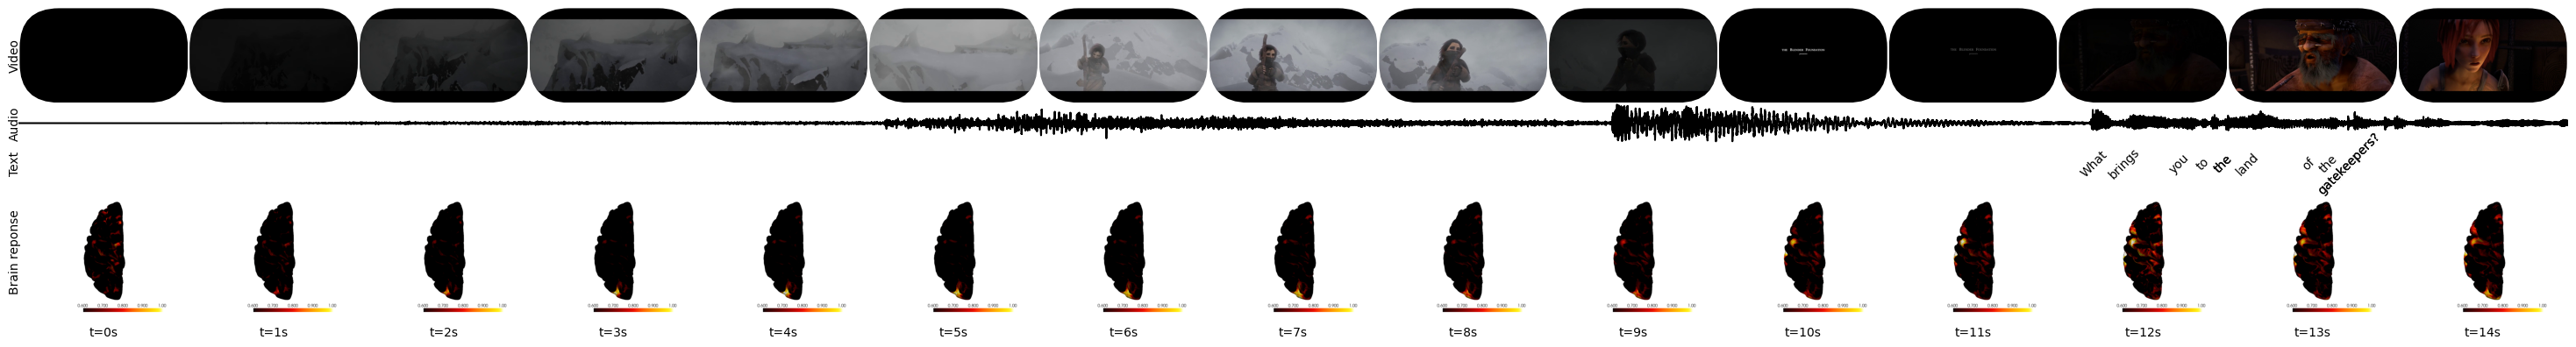

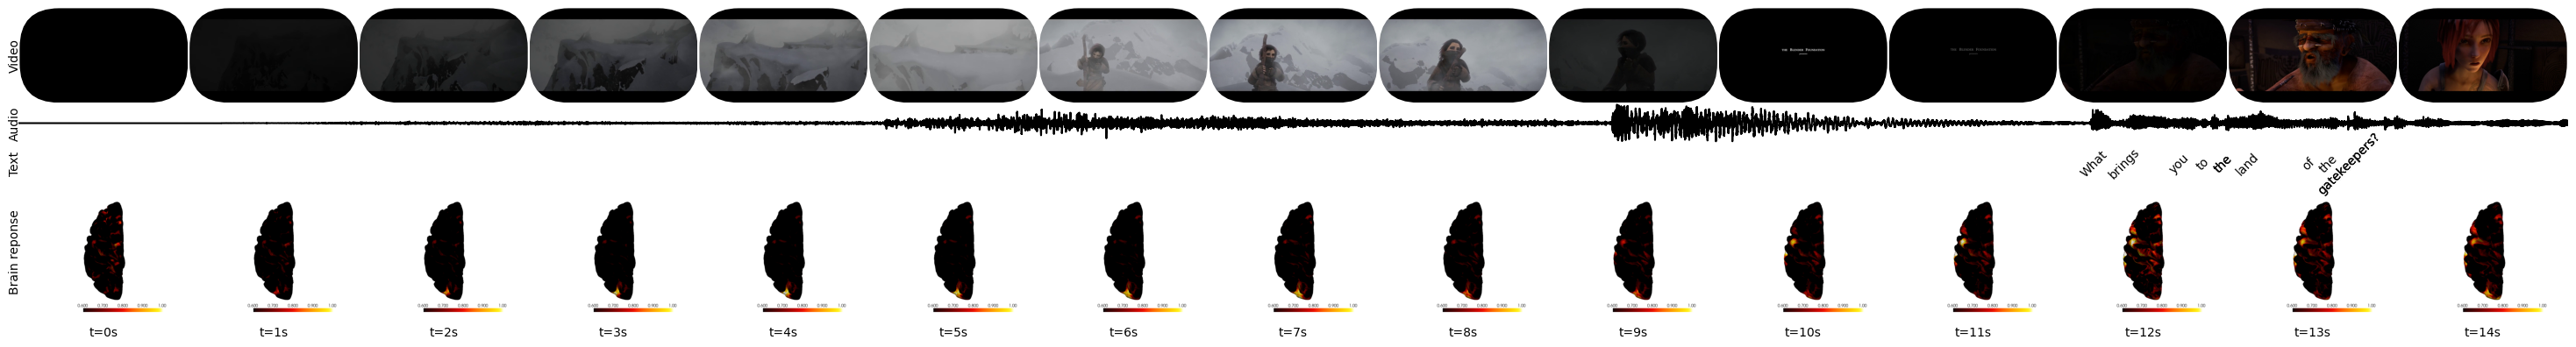

In [22]:
import tribev2.plotting.cortical_pv
import os
import pyvista as pv
from PIL import Image
import nibabel as nib
from nilearn import datasets
import numpy as np

# 1. MALLA (Aseguramos que esté limpia)
fsaverage = datasets.fetch_surf_fsaverage("fsaverage5")
gii = nib.load(fsaverage['pial_left'])
coords, faces = gii.darrays[0].data, gii.darrays[1].data
cells = np.c_[np.full(len(faces), 3), faces]
mesh_final = pv.PolyData(coords, cells)

# 2. PARCHE V8 - Sin métodos de vista ambiguos
def plot_surf_final_v8(self, data, axes, **kwargs):
    vmin, vmax = kwargs.get('vmin', 0.6), kwargs.get('vmax', 1.0)
    
    # Recorte de hemisferio
    if len(data) == 20484:
        data = data[:10242]

    pl = pv.Plotter(off_screen=True, window_size=(600, 600))
    pl.add_mesh(mesh_final, scalars=data, cmap='fire', clim=[vmin, vmax], lighting=True)
    
    # Cambiamos view_side() por una posición de cámara manual o XY
    pl.view_xy() # Vista estándar del plano
    
    tmp_name = os.path.abspath(f"render_v8_{os.getpid()}.png")
    try:
        pl.screenshot(tmp_name)
        img = Image.open(tmp_name).convert("RGBA")
        axes.imshow(img)
    except Exception as e:
        print(f"Error en el render individual: {e}")
    finally:
        pl.close()
        if os.path.exists(tmp_name):
            try: os.remove(tmp_name)
            except: pass
    axes.axis('off')

# 3. INYECTAMOS
tribev2.plotting.cortical_pv.PlotBrainPyvista.plot_surf = plot_surf_final_v8

# 4. EJECUTAMOS
print("🚀 Iniciando renderizado V8 (Cámara XY)...")
n_timesteps = 15
fig = plotter.plot_timesteps(
    preds[:n_timesteps], 
    segments=segments[:n_timesteps], 
    cmap="fire", 
    norm_percentile=99, 
    vmin=.6, 
    show_stimuli=True
)
fig

In [23]:
fig.savefig("resultado_tribe_final.png", dpi=300, bbox_inches='tight')

In [24]:
from nilearn import datasets
import pandas as pd
import numpy as np

# Cargar atlas Destrieux (compatible con fsaverage5)
destrieux = datasets.fetch_atlas_surf_destrieux()
parcellation = destrieux['map_left']  # array de 10242 valores
labels = [l.decode() if isinstance(l, bytes) else l for l in destrieux['labels']]

print(f"Atlas cargado: {len(set(parcellation))} regiones")
print(f"Vértices hemisferio izquierdo: {len(parcellation)}")

[fetch_atlas_surf_destrieux] Added README.md to C:\Users\UNE\nilearn_data

[fetch_atlas_surf_destrieux] Dataset created in C:\Users\UNE\nilearn_data\destrieux_surface

[fetch_atlas_surf_destrieux] Downloading data from 
https://www.nitrc.org/frs/download.php/9343/lh.aparc.a2009s.annot ...

[fetch_atlas_surf_destrieux]  ...done. (1 seconds, 0 min)

[fetch_atlas_surf_destrieux] Downloading data from 
https://www.nitrc.org/frs/download.php/9342/rh.aparc.a2009s.annot ...

[fetch_atlas_surf_destrieux]  ...done. (1 seconds, 0 min)

Atlas cargado: 75 regiones
Vértices hemisferio izquierdo: 10242


C:\Users\UNE\Documents\VSCode\Tri-v2-meta\tmp_plots\ipykernel_29952\1513745629.py:6: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = datasets.fetch_atlas_surf_destrieux()
C:\Users\UNE\Documents\VSCode\Tri-v2-meta\tmp_plots\ipykernel_29952\1513745629.py:6: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = datasets.fetch_atlas_surf_destrieux()


In [31]:
import nibabel as nib
import numpy as np
import pandas as pd
from nilearn import datasets

# Cargar atlas Destrieux (compatible con fsaverage5)
destrieux = datasets.fetch_atlas_surf_destrieux()
parcellation = np.array(destrieux['map_left'], dtype=np.int32)  # fix big-endian
labels = [l.decode() if isinstance(l, bytes) else l for l in destrieux['labels']]

print(f"Atlas cargado: {len(set(parcellation))} regiones")
print(f"Vértices hemisferio izquierdo: {len(parcellation)}")

def top_regiones_por_timestep(preds, parcellation, labels, top_n=5):
    resultados = []
    for t in range(len(preds)):
        activacion = preds[t]
        if len(activacion) == 20484:
            activacion = activacion[:10242]
        df_t = pd.DataFrame({
            'region_id': parcellation,
            'activacion': activacion
        })
        top = (df_t.groupby('region_id')['activacion']
                   .mean()
                   .sort_values(ascending=False)
                   .head(top_n))
        for region_id, valor in top.items():
            resultados.append({
                'timestep': t,
                'region': labels[region_id],
                'activacion_media': round(valor, 4)
            })
    return pd.DataFrame(resultados)

df_regiones = top_regiones_por_timestep(preds, parcellation, labels)

# Exportar CSV completo
df_regiones.to_csv("regiones_activacion.csv", index=False)
print("✅ CSV completo guardado en: regiones_activacion.csv")

# Exportar solo los timesteps de interés
df_filtrado = df_regiones[df_regiones['timestep'].isin([0, 6, 12, 13, 14])]
df_filtrado.to_csv("regiones_activacion_filtrado.csv", index=False)
print("✅ CSV filtrado guardado en: regiones_activacion_filtrado.csv")

display(df_filtrado)

[fetch_atlas_surf_destrieux] Dataset found in C:\Users\UNE\nilearn_data\destrieux_surface

Atlas cargado: 75 regiones
Vértices hemisferio izquierdo: 10242
✅ CSV completo guardado en: regiones_activacion.csv
✅ CSV filtrado guardado en: regiones_activacion_filtrado.csv


C:\Users\UNE\Documents\VSCode\Tri-v2-meta\tmp_plots\ipykernel_29952\3955542504.py:7: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = datasets.fetch_atlas_surf_destrieux()
C:\Users\UNE\Documents\VSCode\Tri-v2-meta\tmp_plots\ipykernel_29952\3955542504.py:7: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = datasets.fetch_atlas_surf_destrieux()


,timestep,region,activacion_media
0,0,S_oc_sup_and_transversal,0.1428
1,0,S_front_middle,0.1400
2,0,G_and_S_cingul-Mid-Ant,0.1262
3,0,S_parieto_occipital,0.1198
4,0,S_pericallosal,0.1022
30,6,S_collat_transv_post,0.5774
31,6,S_oc_middle_and_Lunatus,0.4621
32,6,S_oc_sup_and_transversal,0.3992
33,6,Pole_occipital,0.3085
34,6,G_and_S_occipital_inf,0.3025


✅ Guardado en: activacion_auditiva.png


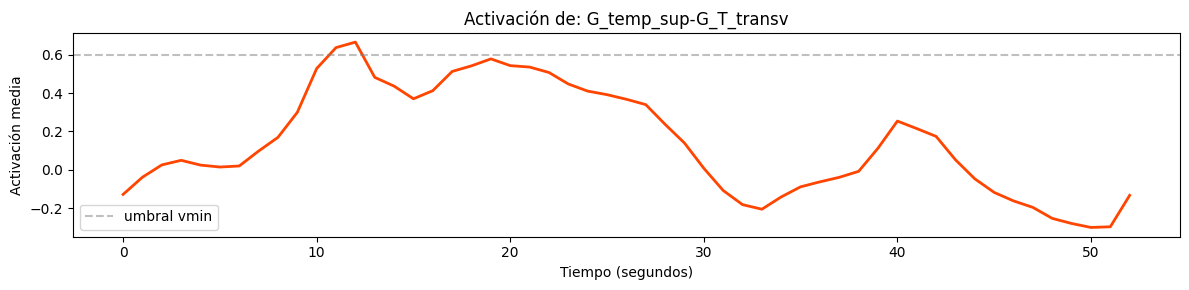

In [30]:
import matplotlib.pyplot as plt

def activacion_region_en_tiempo(preds, parcellation, labels, nombre_region, exportar=None):
    coincidencias = [(i, l) for i, l in enumerate(labels) if nombre_region.lower() in l.lower()]
    
    if not coincidencias:
        print(f"❌ No se encontró '{nombre_region}'.")
        return
    
    region_id, region_nombre = coincidencias[0]
    if len(coincidencias) > 1:
        print(f"⚠️ Múltiples coincidencias, usando la primera: '{region_nombre}'")
    
    vertices = np.where(parcellation == region_id)[0]
    
    valores = []
    for t in range(len(preds)):
        activacion = preds[t]
        if len(activacion) == 20484:
            activacion = activacion[:10242]
        valores.append(activacion[vertices].mean())
    
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(valores, color='orangered', linewidth=2)
    ax.axhline(y=0.6, color='gray', linestyle='--', alpha=0.5, label='umbral vmin')
    ax.set_xlabel("Tiempo (segundos)")
    ax.set_ylabel("Activación media")
    ax.set_title(f"Activación de: {region_nombre}")
    ax.legend()
    plt.tight_layout()
    
    if exportar:
        fig.savefig(exportar, dpi=300, bbox_inches='tight')
        print(f"✅ Guardado en: {exportar}")
    
    plt.show()

# Exporta como PNG
activacion_region_en_tiempo(preds, parcellation, labels, "G_T_transv", exportar="activacion_auditiva.png")

# O como PDF o SVG si lo necesitas para publicación
# activacion_region_en_tiempo(preds, parcellation, labels, "G_T_transv", exportar="activacion_auditiva.pdf")
# activacion_region_en_tiempo(preds, parcellation, labels, "G_T_transv", exportar="activacion_auditiva.svg")

In [32]:
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import datasets

# ─────────────────────────────────────────────
# 1. CARGAR ATLAS
# ─────────────────────────────────────────────
destrieux = datasets.fetch_atlas_surf_destrieux()
parcellation = np.array(destrieux['map_left'], dtype=np.int32)
labels = [l.decode() if isinstance(l, bytes) else l for l in destrieux['labels']]

print(f"Atlas cargado: {len(set(parcellation))} regiones")
print(f"Vértices hemisferio izquierdo: {len(parcellation)}")


# ─────────────────────────────────────────────
# 2. TOP REGIONES POR TIMESTEP (todas)
# ─────────────────────────────────────────────
def top_regiones_por_timestep(preds, parcellation, labels, top_n=5):
    resultados = []
    for t in range(len(preds)):
        activacion = preds[t]
        if len(activacion) == 20484:
            activacion = activacion[:10242]
        df_t = pd.DataFrame({
            'region_id': parcellation,
            'activacion': activacion
        })
        top = (df_t.groupby('region_id')['activacion']
                   .mean()
                   .sort_values(ascending=False)
                   .head(top_n))
        for region_id, valor in top.items():
            resultados.append({
                'timestep': t,
                'region': labels[region_id],
                'activacion_media': round(valor, 4)
            })
    return pd.DataFrame(resultados)

df_regiones = top_regiones_por_timestep(preds, parcellation, labels)

# CSV completo (todos los timesteps)
df_regiones.to_csv("regiones_activacion_completo.csv", index=False)
print(f"✅ CSV completo guardado: {len(df_regiones)} filas → regiones_activacion_completo.csv")

# CSV filtrado (timesteps de interés)
df_filtrado = df_regiones[df_regiones['timestep'].isin([0, 6, 12, 13, 14])]
df_filtrado.to_csv("regiones_activacion_filtrado.csv", index=False)
print("✅ CSV filtrado guardado → regiones_activacion_filtrado.csv")

display(df_filtrado)


# ─────────────────────────────────────────────
# 3. EXPORTAR PREDICCIONES RAW COMPLETAS
#    shape: (n_timesteps, n_vertices) → cada fila = 1 segundo
# ─────────────────────────────────────────────
preds_np = preds.cpu().numpy() if hasattr(preds, 'cpu') else np.array(preds)

# Solo hemisferio izquierdo (primeros 10242 vértices)
preds_left = preds_np[:, :10242]

[fetch_atlas_surf_destrieux] Dataset found in C:\Users\UNE\nilearn_data\destrieux_surface

Atlas cargado: 75 regiones
Vértices hemisferio izquierdo: 10242
✅ CSV completo guardado: 265 filas → regiones_activacion_completo.csv
✅ CSV filtrado guardado → regiones_activacion_filtrado.csv


C:\Users\UNE\Documents\VSCode\Tri-v2-meta\tmp_plots\ipykernel_29952\3420612947.py:10: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = datasets.fetch_atlas_surf_destrieux()
C:\Users\UNE\Documents\VSCode\Tri-v2-meta\tmp_plots\ipykernel_29952\3420612947.py:10: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  destrieux = datasets.fetch_atlas_surf_destrieux()


,timestep,region,activacion_media
0,0,S_oc_sup_and_transversal,0.1428
1,0,S_front_middle,0.1400
2,0,G_and_S_cingul-Mid-Ant,0.1262
3,0,S_parieto_occipital,0.1198
4,0,S_pericallosal,0.1022
30,6,S_collat_transv_post,0.5774
31,6,S_oc_middle_and_Lunatus,0.4621
32,6,S_oc_sup_and_transversal,0.3992
33,6,Pole_occipital,0.3085
34,6,G_and_S_occipital_inf,0.3025


## Predict brain responses to text (via text-to-speech)

TRIBE v2 can also predict brain responses to **text** input. Since the model was trained on naturalistic audio/video stimuli, text is first converted to speech using Google Text-to-Speech (gTTS), then transcribed back to obtain precise word-level timings.

Below, we use a passage from Shakespeare's *Hamlet* as input.

In [ ]:
text = """
To be or not to be, that is the question.
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die, to sleep,
No more; and by a sleep to say we end
The heartache and the thousand natural shocks
"""

text_path = CACHE_FOLDER / "shakespeare.txt"
text_path.write_text(text)

df = model.get_events_dataframe(text_path=text_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

### Run the model

Same as before — we pass the events dataframe to `model.predict()` to get brain activity predictions for each time step.

In [ ]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")

### Visualize predictions on the brain surface

Again, we visualize the first 15 seconds of predicted activity. For audio-only stimuli, the stimulus display shows the spoken words at each time step.

In [ ]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)